# Randomized Nonnegative Matrix Factorization — full implementation

Reproduction of **Erichson, Mendible, Wihlborn & Kutz (2018)**, *Randomized nonnegative matrix
factorization*, Pattern Recognition Letters 104, 1–7.

**What this notebook implements**

| Paper | Notebook |
|---|---|
| §2.3 Probabilistic framework (Eqs. 4–7) | `randomized_range_finder`, `compress` |
| §3.1 Deterministic HALS (Eqs. 8–15) | `hals_nmf` |
| §3.2 Randomized HALS + Algorithm 1 (Eqs. 16–21) | `rnmf_hals` |
| Remarks 1–5 (test matrix, oversampling, power scheme, init, stopping) | arguments of the above |
| Compressed MU baseline (Tepper & Sapiro) | `compressed_mu` |
| §4.1 Handwritten digits (Fig. 1, Tables 1–2) | Part 4 |
| §4.2 Facial features (Fig. 2, Table 3) | Part 5 |
| §4.3 Hyperspectral unmixing (Fig. 3, Table 4) | Part 6 |
| §4.4 Computational performance (Figs. 4–5) | Part 7 |

**Run order:** execute cells top to bottom. Parts 4–7 are independent of each other, so you can skip any
of them. Every dataset cell has an offline fallback, so the notebook runs end to end even without the
original data files.

## Part 0 — Environment

Run once. Skip if you already have these installed.

In [1]:
# Cell 1 — dependencies
# !pip install numpy scipy scikit-learn matplotlib pillow tqdm
# Optional: the authors' own package, for cross-checking your results
# !pip install ristretto
import sys
print(sys.version)

3.14.6 | packaged by Anaconda, Inc. | (main, Jun 18 2026, 21:18:42) [MSC v.1942 64 bit (AMD64)]


In [2]:
# Cell 2 — imports and global configuration
import os
import time
import warnings
from dataclasses import dataclass, field

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

EPS = np.finfo(np.float64).eps
SEED = 42

# Paper defaults (§4 and Conclusion): oversampling p = 20, subspace iterations q = 2,
# tolerance 1e-4, at most 100 iterations.
P_OVERSAMPLE = 20
Q_SUBSPACE = 2
TOL = 1e-4
MAX_ITER = 100

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
np.set_printoptions(precision=4, suppress=True)
print("numpy", np.__version__)

numpy 2.5.2


## Part 1 — The probabilistic framework (§2.3)

Given $X \in \mathbb{R}^{m\times n}$ and target rank $k$:

1. Draw a random test matrix $\Omega \in \mathbb{R}^{n \times (k+p)}$.
   **Remark 1:** entries are drawn *uniformly on [0,1]*, not Gaussian — nonnegative test matrices work
   better on nonnegative data.
2. Sample the range: $Y = X\Omega$ (Eq. 4). **Remark 3:** with power/subspace iterations,
   $Y = (XX^\top)^q X\Omega$, implemented as alternating QR steps for numerical stability
   (a literal power iteration loses digits to round-off).
3. $Q \leftarrow \mathrm{qr}(Y)$, so that $X \approx QQ^\top X$ (Eq. 5).
4. Form the small surrogate $B = Q^\top X \in \mathbb{R}^{(k+p)\times n}$ (Eq. 6), giving $X \approx QB$ (Eq. 7).

**Remark 2:** oversampling $p \in \{10, 20\}$ raises the probability that $Q$ captures the column space.

A useful identity used later for cheap error accounting — since $Q$ has orthonormal columns,
$$\|X - Q\tilde{W}H\|_F^2 = \underbrace{\|X\|_F^2 - \|B\|_F^2}_{\text{compression error, fixed}} + \|B - \tilde{W}H\|_F^2 .$$
So the residual can be monitored entirely in the $k+p$ dimensional space.

In [3]:
# Cell 3 — randomized range finder and compression (Eqs. 4-7, Remarks 1-3)

def randomized_range_finder(X, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE,
                            random_state=None):
    "Return Q with orthonormal columns such that X ~= Q Q^T X."
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    ell = int(min(rank + oversample, min(m, n)))          # Remark 2: oversampling

    Omega = rng.uniform(0.0, 1.0, size=(n, ell))          # Remark 1: nonnegative test matrix
    Y = X @ Omega                                         # Eq. 4
    Q, _ = np.linalg.qr(Y, mode="reduced")

    for _ in range(n_subspace):                           # Remark 3: subspace iteration
        Z, _ = np.linalg.qr(X.T @ Q, mode="reduced")
        Q, _ = np.linalg.qr(X @ Z, mode="reduced")
    return Q


def compress(X, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE, random_state=None):
    "Return (Q, B) with B = Q^T X the (k+p) x n surrogate matrix (Eq. 6)."
    Q = randomized_range_finder(X, rank, oversample, n_subspace, random_state)
    return Q, Q.T @ X

In [4]:
# Cell 4 — initialization (Remark 4), error helpers, stopping criterion (Remark 5)

def init_factors(m, n, rank, X=None, random_state=None):
    "Remark 4: Gaussian entries with negative elements set to zero, then scaled to match X."
    rng = np.random.default_rng(random_state)
    W = np.maximum(rng.standard_normal((m, rank)), 0.0)
    H = np.maximum(rng.standard_normal((rank, n)), 0.0)
    W[W == 0] = 1e-8      # keep columns alive; zero columns are absorbing in HALS
    H[H == 0] = 1e-8
    if X is not None and X.mean() > 0:
        scale = np.sqrt(X.mean() / rank)
        W *= scale
        H *= scale
    return W, H


def relative_error(X, W, H, chunk=4096):
    "||X - WH||_F / ||X||_F without ever forming the m x n product in one block."
    num = 0.0
    for s in range(0, X.shape[1], chunk):
        R = X[:, s:s + chunk] - W @ H[:, s:s + chunk]
        num += float(np.sum(R * R))
    return np.sqrt(num) / np.linalg.norm(X)


def _residual_from_grams(norm_sq, cross, WtW, HHt):
    "||X - WH||_F^2 = ||X||^2 - 2<X, WH> + tr(W^T W H H^T)."
    val = norm_sq - 2.0 * cross + float(np.sum(WtW * HHt))
    return np.sqrt(max(val, 0.0))


def _converged(prev, curr, tol):
    "Remark 5: stop on the relative change of the (log-scale) residual, not a fixed iteration count."
    return prev is not None and abs(prev - curr) <= tol * max(prev, EPS)


@dataclass
class NMFResult:
    W: np.ndarray
    H: np.ndarray
    errors: np.ndarray = field(default_factory=lambda: np.array([]))
    n_iter: int = 0
    time: float = 0.0

    def summary(self, X):
        return dict(time=round(self.time, 3), iters=self.n_iter,
                    error=round(relative_error(X, self.W, self.H), 4))

## Part 2 — Deterministic HALS (§3.1)

HALS is block coordinate descent over rank-one blocks: fix everything except column $W_{:,j}$ and row
$H_{j,:}$ and minimize

$$J_j = \| X^{(j)} - W_{:,j} H_{j,:} \|_F^2, \qquad X^{(j)} = X - \sum_{i \neq j} W_{:,i}H_{i,:}.$$

Setting the gradients (Eqs. 10–11) to zero and rearranging gives the implementation-friendly form of
Kim, He & Park (Eqs. 14–15):

$$W_{:,j} \leftarrow \Big[ W_{:,j} + \frac{(XH^\top)_{:,j} - (WHH^\top)_{:,j}}{(HH^\top)_{jj}} \Big]_+,
\qquad
H_{j,:} \leftarrow \Big[ H_{j,:} + \frac{(X^\top W)_{:,j} - (H^\top W^\top W)_{:,j}}{(W^\top W)_{jj}} \Big]_+^\top$$

The key efficiency point: $XH^\top$, $HH^\top$, $X^\top W$, $W^\top W$ are computed **once per sweep**.
$XH^\top$ and $HH^\top$ do not depend on $W$, so caching them while sweeping $j$ is exact, not an
approximation. Cost per iteration is dominated by the two $O(mnk)$ products — this is exactly what the
randomized version removes.

In [5]:
# Cell 5 — deterministic HALS (Eqs. 14-15). This is the baseline for all speedups.

def hals_nmf(X, rank, max_iter=MAX_ITER, tol=TOL, random_state=None, verbose=False,
             W=None, H=None):
    m, n = X.shape
    if W is None or H is None:
        W, H = init_factors(m, n, rank, X, random_state)
    W, H = W.copy(), H.copy()

    normX = np.linalg.norm(X)
    norm_sq = normX ** 2
    errors, prev = [], None
    t0 = time.perf_counter()

    for it in range(max_iter):
        # ---- update W, column by column (Eq. 14)
        XHt = X @ H.T                     # m x k   -- O(mnk)
        HHt = H @ H.T                     # k x k
        for j in range(rank):
            W[:, j] = np.maximum(W[:, j] + (XHt[:, j] - W @ HHt[:, j]) / (HHt[j, j] + EPS), 0.0)
            if not W[:, j].any():
                W[:, j] = 1e-16

        # ---- update H, row by row (Eq. 15)
        XtW = X.T @ W                     # n x k   -- O(mnk)
        WtW = W.T @ W                     # k x k
        for j in range(rank):
            H[j, :] = np.maximum(H[j, :] + (XtW[:, j] - H.T @ WtW[:, j]) / (WtW[j, j] + EPS), 0.0)
            if not H[j, :].any():
                H[j, :] = 1e-16

        # ---- residual for free from the cached Gram matrices
        HHt = H @ H.T
        cross = float(np.sum(XtW * H.T))
        err = _residual_from_grams(norm_sq, cross, WtW, HHt) / normX
        errors.append(err)
        if verbose and it % 10 == 0:
            print(f"  det  iter {it:3d}  rel.err {err:.6f}")
        if _converged(prev, err, tol):
            break
        prev = err

    return NMFResult(W, H, np.array(errors), len(errors), time.perf_counter() - t0)

## Part 3 — Randomized HALS (§3.2, Algorithm 1)

Replace the high-dimensional problem by the low-dimensional one (Eq. 16):

$$\min_{\tilde W, H} \|B - \tilde W H\|_F^2 \quad\text{s.t.}\quad Q\tilde W \ge 0,\ H \ge 0 .$$

Note where nonnegativity lives: **$H$ must be nonnegative, $\tilde W$ need not be** — only
$W \approx Q\tilde{W}$ must be. The updates become Eqs. 19–20, and the constraint on $W$ is enforced by the
round trip of Eq. 21:

$$\tilde{W}_{:,j} \leftarrow Q^\top \big[ Q \tilde{W}_{:,j} \big]_+ .$$

Per-iteration cost drops from $O(mnk)$ to $O((k+p)nk)$ for the least-squares part, plus $O(mk(k+p))$ for
the projection — i.e. **the algorithm scales with the target rank, not the ambient dimension**, which is
the paper's central claim.

Two implementation details that matter and are easy to get wrong:

* The order in Algorithm 1 is $H$ first, then $\tilde{W}$; $B^\top\tilde{W}$ must be formed *before* the
  $H$ sweep and $B H^\top$ *before* the $\tilde{W}$ sweep, otherwise the residual bookkeeping mixes stale
  and fresh factors.
* Eq. 21 projects **each column** as it is updated, not the whole matrix at the end of the sweep.

In [6]:
# Cell 6 — randomized HALS (Algorithm 1, Eqs. 19-21)

def rnmf_hals(X, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE,
              max_iter=MAX_ITER, tol=TOL, random_state=None, verbose=False):
    m, n = X.shape
    t0 = time.perf_counter()

    # ---- Step 1: compress (Eqs. 4-7). Counted inside the runtime, as in the paper.
    Q, B = compress(X, rank, oversample, n_subspace, random_state)

    W0, H = init_factors(m, n, rank, X, random_state)
    Wt = Q.T @ W0                                  # W~ lives in the (k+p)-dim space

    normX = np.linalg.norm(X)
    normB_sq = float(np.sum(B ** 2))
    offset_sq = max(normX ** 2 - normB_sq, 0.0)    # ||X - QB||^2, fixed compression error

    errors, prev = [], None
    for it in range(max_iter):
        # ---- update H (Eq. 19)
        BtWt = B.T @ Wt                            # n x k  -- O((k+p)nk)
        WtWt = Wt.T @ Wt
        for j in range(rank):
            H[j, :] = np.maximum(H[j, :] + (BtWt[:, j] - H.T @ WtWt[:, j]) / (WtWt[j, j] + EPS), 0.0)
            if not H[j, :].any():
                H[j, :] = 1e-16

        # ---- update W~ (Eq. 20) and project back and forth (Eq. 21)
        BHt = B @ H.T
        HHt = H @ H.T
        for j in range(rank):
            Wt[:, j] = Wt[:, j] + (BHt[:, j] - Wt @ HHt[:, j]) / (HHt[j, j] + EPS)
            Wt[:, j] = Q.T @ np.maximum(Q @ Wt[:, j], 0.0)          # nonnegativity in high-dim space

        # ---- residual, monitored in compressed space (Remark 5 / Eq. 23)
        WtWt = Wt.T @ Wt
        cross = float(np.sum(BHt * Wt))
        resB_sq = normB_sq - 2.0 * cross + float(np.sum(WtWt * HHt))
        err = np.sqrt(max(offset_sq + resB_sq, 0.0)) / normX
        errors.append(err)
        if verbose and it % 10 == 0:
            print(f"  rand iter {it:3d}  rel.err {err:.6f}")
        if _converged(prev, err, tol):
            break
        prev = err

    W = np.maximum(Q @ Wt, 0.0)                    # rotate back to high-dim space
    return NMFResult(W, H, np.array(errors), len(errors), time.perf_counter() - t0)

In [7]:
# Cell 7 — compressed MU baseline (Tepper & Sapiro, 2016) for comparison in the tables.
# Structure-preserving compression: left basis L for H updates, right basis R for W updates.

def compressed_mu(X, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE,
                  max_iter=5000, tol=TOL, random_state=None, check_every=10):
    m, n = X.shape
    t0 = time.perf_counter()

    L = randomized_range_finder(X, rank, oversample, n_subspace, random_state)      # m x l
    R = randomized_range_finder(X.T, rank, oversample, n_subspace, random_state)    # n x l
    XL = L.T @ X          # l x n
    XR = X @ R            # m x l

    W, H = init_factors(m, n, rank, X, random_state)
    normX = np.linalg.norm(X)
    errors, prev, it = [], None, 0

    for it in range(max_iter):
        WL = L.T @ W
        H *= np.maximum(WL.T @ XL, 0.0) / ((WL.T @ WL) @ H + 1e-9)
        HR = H @ R
        W *= np.maximum(XR @ HR.T, 0.0) / (W @ (HR @ HR.T) + 1e-9)

        if it % check_every == 0 or it == max_iter - 1:
            err = relative_error(X, W, H)
            errors.append(err)
            if _converged(prev, err, tol):
                break
            prev = err

    return NMFResult(W, H, np.array(errors), it + 1, time.perf_counter() - t0)

## Part 3b — Correctness checks

Before touching real data, verify: (a) the compression identity, (b) nonnegativity of the returned
factors, (c) that randomized HALS recovers an exactly low-rank nonnegative matrix, and (d) that it is
faster than deterministic HALS on a matrix where $m \gg k$.

In [8]:
# Cell 8 — sanity checks

rng = np.random.default_rng(SEED)
m, n, r = 5000, 800, 20
Wtrue = np.maximum(rng.standard_normal((m, r)), 0.0)
Htrue = np.maximum(rng.standard_normal((r, n)), 0.0)
Xtest = Wtrue @ Htrue

Q, B = compress(Xtest, r, random_state=SEED)
lhs = np.linalg.norm(Xtest - Q @ B) ** 2
rhs = np.linalg.norm(Xtest) ** 2 - np.linalg.norm(B) ** 2
print(f"(a) ||X-QB||^2 = {lhs:.3e}   vs   ||X||^2-||B||^2 = {rhs:.3e}")
print(f"    Q orthonormal: {np.allclose(Q.T @ Q, np.eye(Q.shape[1]))}")

det = hals_nmf(Xtest, r, random_state=SEED)
rnd = rnmf_hals(Xtest, r, random_state=SEED)

print(f"(b) min(W)={rnd.W.min():.2e}  min(H)={rnd.H.min():.2e}  -> nonnegative: "
      f"{rnd.W.min() >= 0 and rnd.H.min() >= 0}")
print(f"(c) rank-{r} recovery, randomized rel.err = {relative_error(Xtest, rnd.W, rnd.H):.2e}")
print(f"(d) deterministic {det.time:.2f}s ({det.n_iter} it) | randomized {rnd.time:.2f}s "
      f"({rnd.n_iter} it) | speedup x{det.time / rnd.time:.1f}")

assert rnd.W.min() >= 0 and rnd.H.min() >= 0
assert relative_error(Xtest, rnd.W, rnd.H) < 1e-2
print("\nAll checks passed.")

(a) ||X-QB||^2 = 2.617e-23   vs   ||X||^2-||B||^2 = 4.470e-08
    Q orthonormal: True
(b) min(W)=0.00e+00  min(H)=0.00e+00  -> nonnegative: True
(c) rank-20 recovery, randomized rel.err = 3.13e-08
(d) deterministic 0.59s (79 it) | randomized 0.60s (75 it) | speedup x1.0

All checks passed.


In [9]:
# Cell 9 — shared plotting + benchmarking utilities used by Parts 4-7

def plot_gallery(basis, image_shape, n_row=4, n_col=4, title="", cmap="Reds", figsize=(4.2, 4.2)):
    "basis: (n_pixels, k) matrix whose columns are vectorized images."
    fig, axes = plt.subplots(n_row, n_col, figsize=figsize)
    for i, ax in enumerate(axes.ravel()):
        ax.axis("off")
        if i < basis.shape[1]:
            ax.imshow(basis[:, i].reshape(image_shape), cmap=cmap)
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    return fig


def make_table(results, baseline="Deterministic HALS", X=None):
    "results: dict name -> NMFResult. Prints the paper-style time/speedup/iterations/error table."
    base_t = results[baseline].time
    rows = []
    for name, res in results.items():
        s = res.summary(X)
        speed = "-" if name == baseline else f"{base_t / res.time:.1f}"
        rows.append((name, f"{s['time']:.2f}", speed, str(s["iters"]), f"{s['error']:.3f}"))
    head = ("Method", "Time (s)", "Speedup", "Iterations", "Error")
    widths = [max(len(r[i]) for r in rows + [head]) for i in range(5)]
    line = "  ".join(h.ljust(w) for h, w in zip(head, widths))
    print(line)
    print("-" * len(line))
    for r in rows:
        print("  ".join(c.ljust(w) for c, w in zip(r, widths)))
    return rows


def svd_baseline(X, rank):
    "Truncated SVD reference (best possible rank-k error) with timing."
    t0 = time.perf_counter()
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    U, s, Vt = U[:, :rank], s[:rank], Vt[:rank]
    dt = time.perf_counter() - t0
    err = np.linalg.norm(X - (U * s) @ Vt) / np.linalg.norm(X)
    return U, s, Vt, dt, err

## Part 4 — §4.1 Handwritten digits (MNIST)

The data matrix is **pixels × samples**: each 28×28 image is vectorized and stacked as a column, giving
$X \in \mathbb{R}^{784 \times 60000}$. Then $W$ (784 × k) holds the basis images and $H$ (k × 60000) the
coefficients.

`fetch_openml("mnist_784")` downloads ~55 MB the first time. If you have no network, the cell falls back
to scikit-learn's 8×8 `load_digits` — everything still runs, but the speedups will be small because that
matrix is tiny (the whole point of randomization is large $m$ or $n$).

In [10]:
# Cell 10 — load MNIST (with offline fallback)

def load_mnist(n_train=60000, n_test=10000):
    try:
        from sklearn.datasets import fetch_openml
        d = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
        Xall = d.data.astype(np.float64) / 255.0
        yall = d.target.astype(int)
        img_shape = (28, 28)
        Xtr, ytr = Xall[:n_train].T, yall[:n_train]
        Xte, yte = Xall[n_train:n_train + n_test].T, yall[n_train:n_train + n_test]
        print(f"MNIST loaded: train {Xtr.shape}, test {Xte.shape}")
    except Exception as exc:
        from sklearn.datasets import load_digits
        from sklearn.model_selection import train_test_split
        print(f"[fallback] MNIST unavailable ({type(exc).__name__}); using 8x8 load_digits instead.")
        d = load_digits()
        Xa, Xb, ya, yb = train_test_split(d.data / 16.0, d.target, test_size=0.3,
                                          random_state=SEED, stratify=d.target)
        Xtr, ytr, Xte, yte, img_shape = Xa.T, ya, Xb.T, yb, (8, 8)
        print(f"digits loaded: train {Xtr.shape}, test {Xte.shape}")
    return Xtr, ytr, Xte, yte, img_shape


X_tr, y_tr, X_te, y_te, IMG_SHAPE = load_mnist()
K_DIGITS = 16

[fallback] MNIST unavailable (ImportError); using 8x8 load_digits instead.
digits loaded: train (64, 1257), test (64, 540)


In [11]:
# Cell 11 — Table 1: computational results on MNIST (target rank k = 16)

res_mnist = {}
res_mnist["Deterministic HALS"] = hals_nmf(X_tr, K_DIGITS, random_state=SEED)
res_mnist["Randomized HALS"] = rnmf_hals(X_tr, K_DIGITS, random_state=SEED)
res_mnist["Compressed MU"] = compressed_mu(X_tr, K_DIGITS, random_state=SEED)

print("Table 1 -- MNIST, k = 16\n")
make_table(res_mnist, X=X_tr)

U, s, Vt, t_svd, e_svd = svd_baseline(X_tr, K_DIGITS)
print(f"\nSVD reference: {t_svd:.2f}s, error {e_svd:.3f}  (lower bound on the rank-k error)")

Table 1 -- MNIST, k = 16

Method              Time (s)  Speedup  Iterations  Error
--------------------------------------------------------
Deterministic HALS  0.15      -        100         0.258
Randomized HALS     0.13      1.1      100         0.269
Compressed MU       0.79      0.2      1201        0.261

SVD reference: 0.01s, error 0.217  (lower bound on the rank-k error)


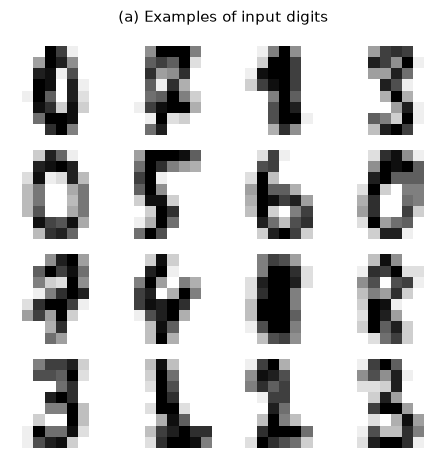

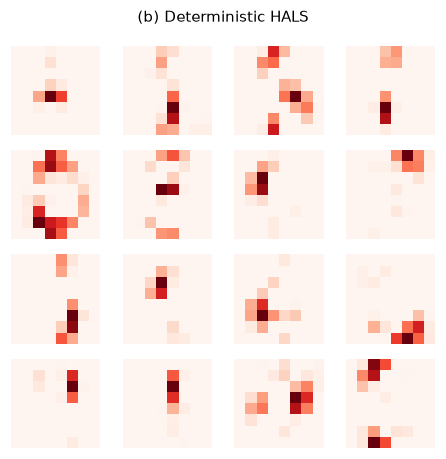

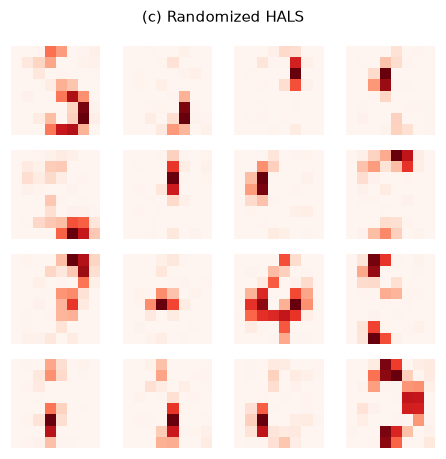

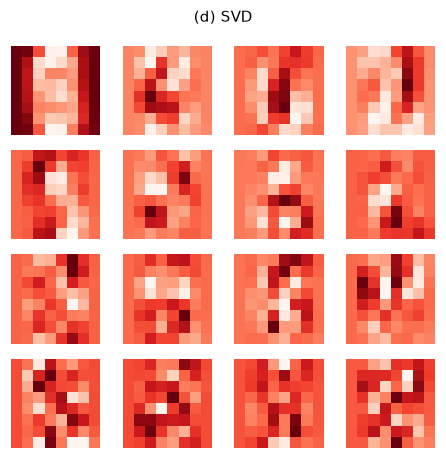

Deterministic HALS     sparsity of W (fraction of zeros): 0.75
Randomized HALS        sparsity of W (fraction of zeros): 0.43
SVD                    fraction of negative entries: 0.51


In [12]:
# Cell 12 — Figure 1: dominant basis images (input / deterministic / randomized / SVD)

plot_gallery(X_tr[:, :16], IMG_SHAPE, title="(a) Examples of input digits", cmap="gray_r")
plot_gallery(res_mnist["Deterministic HALS"].W, IMG_SHAPE, title="(b) Deterministic HALS")
plot_gallery(res_mnist["Randomized HALS"].W, IMG_SHAPE, title="(c) Randomized HALS")
plot_gallery(U, IMG_SHAPE, title="(d) SVD")
plt.show()

# NMF gives sparse, parts-based, all-nonnegative atoms; SVD gives holistic, mixed-sign ones.
for name in ("Deterministic HALS", "Randomized HALS"):
    W = res_mnist[name].W
    print(f"{name:22s} sparsity of W (fraction of zeros): {(W < 1e-10).mean():.2f}")
print(f"{'SVD':22s} fraction of negative entries: {(U < 0).mean():.2f}")

In [13]:
# Cell 13 — Table 2: k-nearest-neighbours classification on the NMF features (k_nn = 3)
# Test coefficients are obtained by solving min_h ||x - W h||, h >= 0 with the fitted basis W.

from scipy.optimize import nnls
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_recall_fscore_support


def project_nonneg(W, X, fast=True):
    "Encode columns of X in the basis W with nonnegative coefficients."
    if fast:  # clipped least squares: much faster, accurate enough for kNN features
        Hc = np.linalg.lstsq(W, X, rcond=None)[0]
        return np.maximum(Hc, 0.0)
    return np.column_stack([nnls(W, X[:, i])[0] for i in range(X.shape[1])])


def classify(train_feats, test_feats, y_tr, y_te, n_neighbors=3):
    knn = KNeighborsClassifier(n_neighbors=n_neighbors).fit(train_feats.T, y_tr)
    out = {}
    for tag, F, y in (("train", train_feats, y_tr), ("test", test_feats, y_te)):
        pred = knn.predict(F.T)
        p, r, f1, _ = precision_recall_fscore_support(y, pred, average="weighted", zero_division=0)
        out[tag] = (p, r, f1)
    return out


rows = {}
for name in ("Deterministic HALS", "Randomized HALS", "Compressed MU"):
    W = res_mnist[name].W
    rows[name] = classify(res_mnist[name].H, project_nonneg(W, X_te), y_tr, y_te)
rows["SVD"] = classify(U.T @ X_tr, U.T @ X_te, y_tr, y_te)

print("Table 2 -- kNN (k=3) on the rank-16 features\n")
for split in ("train", "test"):
    print(f"({'a' if split == 'train' else 'b'}) {split.capitalize()} data.")
    print(f"{'':22s}{'Precision':>11}{'Recall':>9}{'F1-score':>10}")
    for name, v in rows.items():
        p, r, f1 = v[split]
        print(f"{name:22s}{p:11.2f}{r:9.2f}{f1:10.2f}")
    print()

Table 2 -- kNN (k=3) on the rank-16 features

(a) Train data.
                        Precision   Recall  F1-score
Deterministic HALS           0.96     0.96      0.96
Randomized HALS              0.96     0.96      0.96
Compressed MU                0.85     0.85      0.85
SVD                          0.99     0.99      0.99

(b) Test data.
                        Precision   Recall  F1-score
Deterministic HALS           0.91     0.91      0.91
Randomized HALS              0.89     0.89      0.89
Compressed MU                0.69     0.69      0.69
SVD                          0.99     0.99      0.99



## Part 5 — §4.2 Facial feature extraction

The paper uses the cropped Yale Face Database B: 2410 grayscale images of size 192×168, vectorized into a
**32256 × 2410** matrix. That shape (very tall) is where randomization shines — the paper reports a
13.4× speedup.

Yale B is not distributed through scikit-learn. Two options:

* **Yale B** — download `CroppedYale` (PGM files) and point `YALE_DIR` at the folder.
* **Fallback** — `fetch_olivetti_faces` (400 images, 64×64) downloads automatically; if that also fails,
  the cell synthesizes a face-like dataset so the rest of the notebook still runs.

In [14]:
# Cell 14 — load faces

YALE_DIR = None   # e.g. "./CroppedYale"  (folder of yaleB**/*.pgm files)


def load_faces(yale_dir=YALE_DIR, downsample=2):
    if yale_dir and os.path.isdir(yale_dir):
        from PIL import Image
        paths = [os.path.join(root, f)
                 for root, _, files in os.walk(yale_dir)
                 for f in sorted(files) if f.lower().endswith(".pgm") and "Ambient" not in f]
        imgs = []
        for p in sorted(paths):
            a = np.asarray(Image.open(p), dtype=np.float64)[::downsample, ::downsample]
            imgs.append(a)
        A = np.stack(imgs)
        print(f"Yale B loaded: {A.shape[0]} images of {A.shape[1:]}")
        return A.reshape(A.shape[0], -1).T / 255.0, A.shape[1:]
    try:
        from sklearn.datasets import fetch_olivetti_faces
        f = fetch_olivetti_faces(shuffle=False)
        print(f"[fallback] Olivetti faces: {f.images.shape}")
        return f.data.T.astype(np.float64), f.images.shape[1:]
    except Exception as exc:
        print(f"[fallback] no face dataset available ({type(exc).__name__}); synthesizing one.")
        rng = np.random.default_rng(SEED)
        h = w = 64
        parts = np.maximum(rng.standard_normal((h * w, 12)), 0)
        for j in range(12):
            img = np.zeros((h, w))
            cy, cx = rng.integers(10, h - 10), rng.integers(10, w - 10)
            yy, xx = np.mgrid[0:h, 0:w]
            img = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * 8.0 ** 2))
            parts[:, j] = img.ravel()
        coef = np.maximum(rng.standard_normal((12, 1200)), 0)
        return parts @ coef, (h, w)


X_faces, FACE_SHAPE = load_faces()
K_FACES = 16
print("data matrix:", X_faces.shape)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\aksha\scikit_learn_data
[fallback] Olivetti faces: (400, 64, 64)
data matrix: (4096, 400)


Table 3 -- faces, k = 16

Method              Time (s)  Speedup  Iterations  Error
--------------------------------------------------------
Deterministic HALS  0.22      -        100         0.131
Randomized HALS     0.13      1.8      100         0.130
Compressed MU       5.01      0.0      1721        0.130


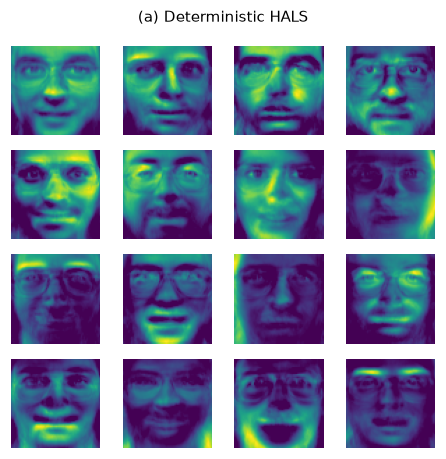

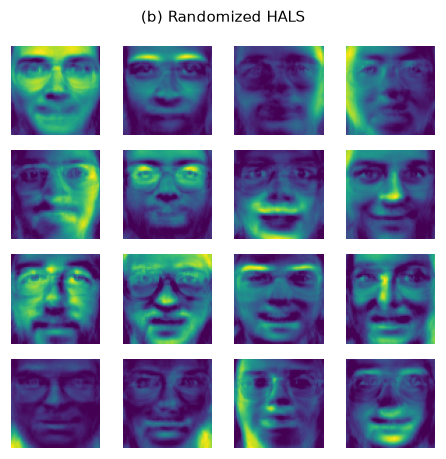

In [15]:
# Cell 15 — Table 3 and Figure 2: facial features

res_faces = {}
res_faces["Deterministic HALS"] = hals_nmf(X_faces, K_FACES, random_state=SEED)
res_faces["Randomized HALS"] = rnmf_hals(X_faces, K_FACES, random_state=SEED)
res_faces["Compressed MU"] = compressed_mu(X_faces, K_FACES, random_state=SEED)

print("Table 3 -- faces, k = 16\n")
make_table(res_faces, X=X_faces)

plot_gallery(res_faces["Deterministic HALS"].W, FACE_SHAPE,
             title="(a) Deterministic HALS", cmap="viridis")
plot_gallery(res_faces["Randomized HALS"].W, FACE_SHAPE,
             title="(b) Randomized HALS", cmap="viridis")
plt.show()

## Part 6 — §4.3 Hyperspectral unmixing

Linear mixing model: $p_i = W H_{:,i}$, so the data matrix is **bands × pixels**. $W$ (bands × 4) holds
the endmember spectra (asphalt, grass, tree, roof) and each column of $H$ holds that pixel's abundances.

The paper uses the *Urban* image: 307×307 pixels, 210 bands reduced to 162 after removing water-vapour
bands. It is usually distributed as `Urban_R162.mat` (already reduced) or `Urban_F210.mat`. Set
`URBAN_MAT` to the file path; otherwise the cell builds a synthetic 4-endmember cube with the same
structure so the unmixing code path is still exercised.

In [16]:
# Cell 16 — load the hyperspectral cube

URBAN_MAT = None   # e.g. "./Urban_R162.mat"


def load_urban(path=URBAN_MAT):
    if path and os.path.isfile(path):
        from scipy.io import loadmat
        mat = loadmat(path)
        Y = np.asarray(mat["Y"], dtype=np.float64)          # bands x pixels
        nRow = int(np.squeeze(mat.get("nRow", 307)))
        nCol = int(np.squeeze(mat.get("nCol", 307)))
        Y = Y / (Y.max() + EPS)
        print(f"Urban loaded: {Y.shape[0]} bands x {Y.shape[1]} pixels, image {nRow}x{nCol}")
        return Y, (nRow, nCol)

    print("[fallback] Urban .mat not found; synthesizing a 4-endmember cube.")
    rng = np.random.default_rng(SEED)
    nRow = nCol = 200
    bands = 162
    x = np.linspace(0, 1, bands)
    endmembers = np.stack([
        np.exp(-((x - 0.2) ** 2) / 0.01) + 0.3 * x,
        np.exp(-((x - 0.55) ** 2) / 0.005) + 0.5 * np.exp(-((x - 0.8) ** 2) / 0.02),
        0.8 * np.exp(-((x - 0.7) ** 2) / 0.03) + 0.2,
        np.clip(1.0 - x, 0, None) + 0.15,
    ], axis=1)
    yy, xx = np.mgrid[0:nRow, 0:nCol] / nRow
    maps = np.stack([
        np.exp(-((yy - 0.3) ** 2 + (xx - 0.3) ** 2) / 0.05),
        np.exp(-((yy - 0.7) ** 2 + (xx - 0.6) ** 2) / 0.04),
        (np.sin(6 * np.pi * xx) ** 2) * (yy > 0.5),
        np.exp(-((xx - 0.85) ** 2) / 0.01),
    ], axis=0).reshape(4, -1)
    maps /= maps.sum(0, keepdims=True) + EPS
    Y = endmembers @ maps
    Y += 0.01 * np.abs(rng.standard_normal(Y.shape))
    return Y, (nRow, nCol)


X_hsi, HSI_SHAPE = load_urban()
K_HSI = 4
print("data matrix:", X_hsi.shape)

[fallback] Urban .mat not found; synthesizing a 4-endmember cube.
data matrix: (162, 40000)


Table 4 -- hyperspectral image, k = 4

Method              Time (s)  Speedup  Iterations  Error
--------------------------------------------------------
Deterministic HALS  0.67      -        77          0.012
Randomized HALS     0.18      3.7      68          0.012
Compressed MU       21.16     0.0      3101        0.012


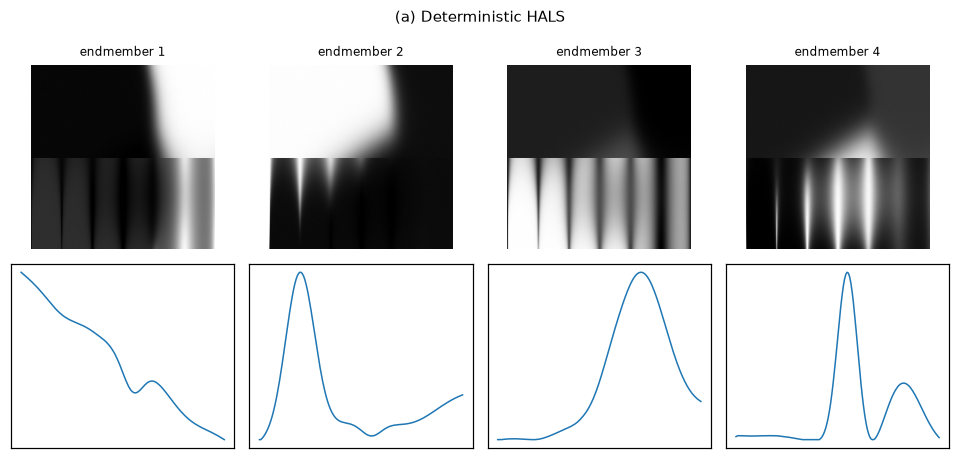

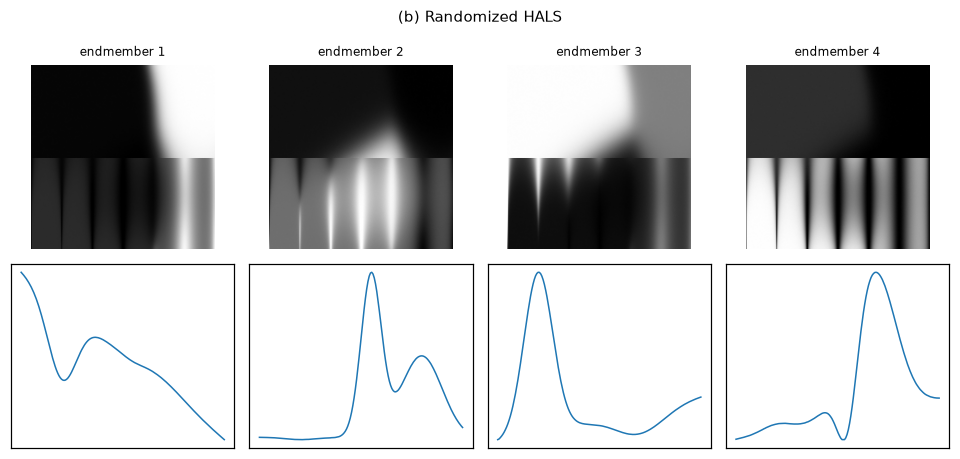

In [17]:
# Cell 17 — Table 4 and Figure 3: endmembers and abundance maps

res_hsi = {}
res_hsi["Deterministic HALS"] = hals_nmf(X_hsi, K_HSI, random_state=SEED)
res_hsi["Randomized HALS"] = rnmf_hals(X_hsi, K_HSI, oversample=10, random_state=SEED)
res_hsi["Compressed MU"] = compressed_mu(X_hsi, K_HSI, oversample=10, random_state=SEED)

print("Table 4 -- hyperspectral image, k = 4\n")
make_table(res_hsi, X=X_hsi)


def plot_unmixing(res, shape, title):
    W, H = res.W, res.H
    order = np.argsort(-H.sum(1))                  # sort components by total abundance
    fig, axes = plt.subplots(2, W.shape[1], figsize=(2.2 * W.shape[1], 4.2))
    for c, j in enumerate(order):
        axes[0, c].imshow(H[j].reshape(shape), cmap="gray")
        axes[0, c].set_title(f"endmember {c + 1}", fontsize=8)
        axes[0, c].axis("off")
        axes[1, c].plot(W[:, j], lw=1)
        axes[1, c].set_xticks([])
        axes[1, c].set_yticks([])
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()


plot_unmixing(res_hsi["Deterministic HALS"], HSI_SHAPE, "(a) Deterministic HALS")
plot_unmixing(res_hsi["Randomized HALS"], HSI_SHAPE, "(b) Randomized HALS")
plt.show()

## Part 7 — §4.4 Computational performance (Figures 4 and 5)

Synthetic low-rank nonnegative matrices of rank $r=50$, in two shapes: tall-and-skinny
(50000×3000) and fat (20000×15000). Relative error, runtime and speedup are plotted against the target
rank $k$.

**Memory warning.** 50000×3000 in float64 is 1.2 GB and 20000×15000 is 2.4 GB. `FULL_SCALE = False`
uses reduced dimensions (same qualitative behaviour, minutes instead of hours). Set it to `True` only on a
machine with ≥32 GB of RAM, and drop `N_RUNS` to 3–5 first.

In [18]:
# Cell 18 — benchmark harness

FULL_SCALE = False
N_RUNS = 3                    # the paper averages over 20 runs
TARGET_RANKS = [5, 10, 20, 30, 40, 50]
TRUE_RANK = 50

DIMS = ([(50000, 3000), (20000, 15000)] if FULL_SCALE
        else [(20000, 1500), (8000, 6000)])


def make_lowrank(m, n, rank, noise=0.0, random_state=None):
    rng = np.random.default_rng(random_state)
    W = np.maximum(rng.standard_normal((m, rank)), 0.0)
    H = np.maximum(rng.standard_normal((rank, n)), 0.0)
    X = W @ H
    if noise > 0:
        X = X + noise * X.std() * np.abs(rng.standard_normal(X.shape))
    return X


def benchmark(m, n, target_ranks=TARGET_RANKS, n_runs=N_RUNS, noise=0.0, with_cmu=True):
    out = {k: {"det": [], "rand": [], "cmu": []} for k in ("time", "error")}
    grid = {"det": [], "rand": [], "cmu": []}
    for k in target_ranks:
        acc = {name: {"t": [], "e": []} for name in ("det", "rand", "cmu")}
        for run in range(n_runs):
            X = make_lowrank(m, n, TRUE_RANK, noise=noise, random_state=SEED + run)
            r1 = hals_nmf(X, k, random_state=SEED + run)
            acc["det"]["t"].append(r1.time); acc["det"]["e"].append(relative_error(X, r1.W, r1.H))
            r2 = rnmf_hals(X, k, random_state=SEED + run)
            acc["rand"]["t"].append(r2.time); acc["rand"]["e"].append(relative_error(X, r2.W, r2.H))
            if with_cmu:
                r3 = compressed_mu(X, k, max_iter=5000, random_state=SEED + run)
                acc["cmu"]["t"].append(r3.time); acc["cmu"]["e"].append(relative_error(X, r3.W, r3.H))
            del X
        for name in ("det", "rand", "cmu"):
            if acc[name]["t"]:
                grid[name].append((k, np.mean(acc[name]["t"]), np.mean(acc[name]["e"])))
        print(f"  k={k:3d} done  det {np.mean(acc['det']['t']):6.2f}s | "
              f"rand {np.mean(acc['rand']['t']):6.2f}s")
    return grid


def plot_benchmark(grid, title):
    labels = {"det": ("Deterministic HALS", "tab:green", "s-"),
              "rand": ("Randomized HALS", "tab:red", "o-"),
              "cmu": ("Compressed MU", "tab:blue", "d--")}
    fig, axes = plt.subplots(3, 1, figsize=(4.4, 8), sharex=True)
    for name, (lab, col, sty) in labels.items():
        if not grid[name]:
            continue
        ks = [g[0] for g in grid[name]]
        axes[0].semilogy(ks, [g[2] for g in grid[name]], sty, color=col, label=lab, ms=4)
        axes[1].semilogy(ks, [g[1] for g in grid[name]], sty, color=col, label=lab, ms=4)
    base = {g[0]: g[1] for g in grid["det"]}
    for name in ("rand", "cmu"):
        if not grid[name]:
            continue
        lab, col, sty = labels[name]
        ks = [g[0] for g in grid[name]]
        axes[2].plot(ks, [base[g[0]] / g[1] for g in grid[name]], sty, color=col, label=lab, ms=4)
    axes[0].set_ylabel("Relative error"); axes[0].legend(fontsize=7)
    axes[1].set_ylabel("Time in s")
    axes[2].set_ylabel("Speedup"); axes[2].set_xlabel("Target rank")
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()

In [ ]:
# Cell 19 — Figure 4: clean rank-50 matrices

grids_clean = {}
for (m, n) in DIMS:
    print(f"Benchmarking {m} x {n} (clean)")
    grids_clean[(m, n)] = benchmark(m, n, noise=0.0)
    plot_benchmark(grids_clean[(m, n)], f"Dimension: {m:,} x {n:,}")
plt.show()

Benchmarking 20000 x 1500 (clean)
  k=  5 done  det   3.06s | rand   0.63s
  k= 10 done  det   3.27s | rand   0.51s
  k= 20 done  det   3.98s | rand   1.02s
  k= 30 done  det   6.06s | rand   2.20s
  k= 40 done  det   7.01s | rand   3.71s
  k= 50 done  det   8.70s | rand   5.13s
Benchmarking 8000 x 6000 (clean)
  k=  5 done  det   0.17s | rand   0.29s


In [ ]:
# Cell 20 — Figure 5: same matrices perturbed with 10% white noise

grids_noisy = {}
for (m, n) in DIMS:
    print(f"Benchmarking {m} x {n} (10% noise)")
    grids_noisy[(m, n)] = benchmark(m, n, noise=0.1)
    plot_benchmark(grids_noisy[(m, n)], f"Dimension: {m:,} x {n:,}, 10% noise")
plt.show()

## Part 8 — Ablations: oversampling $p$ and subspace iterations $q$

The paper's defaults are $p = 20$, $q = 2$ (Remarks 2–3 and the Conclusion). These two cells show *why*:
$p$ buys accuracy cheaply, and $q$ matters most when the singular spectrum decays slowly — which is
exactly the noisy case.

In [ ]:
# Cell 21 — effect of p and q on accuracy and runtime

Xab = make_lowrank(15000, 1200, TRUE_RANK, noise=0.1, random_state=SEED)
k_ab = 30

print(f"{'p':>4}{'q':>4}{'time (s)':>10}{'rel. error':>13}")
print("-" * 31)
for q in (0, 1, 2, 4):
    for p in (0, 5, 10, 20, 50):
        r = rnmf_hals(Xab, k_ab, oversample=p, n_subspace=q, random_state=SEED)
        print(f"{p:>4}{q:>4}{r.time:>10.2f}{relative_error(Xab, r.W, r.H):>13.5f}")

ref = hals_nmf(Xab, k_ab, random_state=SEED)
print(f"\ndeterministic HALS: {ref.time:.2f}s, error {relative_error(Xab, ref.W, ref.H):.5f}")

In [ ]:
# Cell 22 — convergence curves: error vs iteration and vs wall-clock time

Xc = make_lowrank(20000, 1500, TRUE_RANK, noise=0.1, random_state=SEED)
kc = 40
rd = hals_nmf(Xc, kc, max_iter=100, random_state=SEED)
rr = rnmf_hals(Xc, kc, max_iter=100, random_state=SEED)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].semilogy(rd.errors, "s-", color="tab:green", ms=3, label="Deterministic HALS")
ax[0].semilogy(rr.errors, "o-", color="tab:red", ms=3, label="Randomized HALS")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Relative error"); ax[0].legend(fontsize=8)
ax[1].semilogy(np.linspace(0, rd.time, len(rd.errors)), rd.errors, "s-", color="tab:green", ms=3)
ax[1].semilogy(np.linspace(0, rr.time, len(rr.errors)), rr.errors, "o-", color="tab:red", ms=3)
ax[1].set_xlabel("Wall-clock time (s)"); ax[1].set_ylabel("Relative error")
fig.tight_layout(); plt.show()

print(f"per-iteration cost: deterministic {rd.time / rd.n_iter * 1000:.1f} ms, "
      f"randomized {rr.time / rr.n_iter * 1000:.1f} ms")

## Part 9 — Notes, pitfalls, and extensions

**Pitfalls I hit while implementing this**

1. *Residual bookkeeping.* $B^\top\tilde{W}$ is formed before the $H$ sweep and $BH^\top$ before the
   $\tilde{W}$ sweep. If you compute the cross term $\langle B, \tilde{W}H\rangle$ from the stale
   $B^\top \tilde{W}$, the monitored error collapses toward zero while the true error stays large, and
   the stopping rule fires far too early.
2. *Eq. 21 is per column.* Projecting the whole $\tilde{W}$ once at the end of the sweep changes the
   fixed point.
3. *Dead components.* Once a column of $W$ or a row of $H$ becomes all-zero, HALS can never revive it
   (the update is multiplied by zero denominators). Clamping to a tiny positive value avoids silent
   rank collapse.
4. *Numerically stable power iterations.* Remark 3 is explicit: implement $(XX^\top)^qX\Omega$ as
   alternating QR (subspace iteration). The literal version loses the small singular directions to
   round-off, which visibly distorts the basis images.
5. *Nonnegative $\Omega$.* Remark 1 — uniform on [0,1] beats Gaussian on nonnegative data. Try flipping
   it in `randomized_range_finder` and re-running Part 8 to see the difference.

**Reporting speedups honestly.** The compression step (QR + two subspace iterations) is inside the timed
region of `rnmf_hals`, which is what makes the comparison fair. Speedups grow with $m/k$, so measure on
matrices where the ambient dimension actually dwarfs the target rank; on a 64×1797 digits matrix the
randomized version can be *slower*.

**Cross-check against the authors.** `pip install ristretto`, then compare:

```python
from ristretto.nmf import compute_rnmf_fhals
W_ref, H_ref = compute_rnmf_fhals(X, rank=16, oversample=20, n_subspace=2)
```

**Extensions suggested in §5**

* GPU implementation — swap `numpy` for `cupy`; the QR and the two GEMMs per sweep dominate.
* Randomized nonnegative *tensor* factorization, following Erichson et al. (randomized CP).
* Single-pass compression for streaming data, so $X$ is never fully resident in memory.